In [1]:
import torch

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

from PIL import ImageOps

import matplotlib.pyplot as plt

from torch import nn
from torchinfo import summary

from tqdm.auto import tqdm
from timeit import default_timer as timer

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix


torch.use_deterministic_algorithms(True)

c:\env\gestos\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_directory = "dataset/divided/train/"
val_directory = "dataset/divided/val/"
test_directory = "dataset/divided/test/"

In [ ]:
from PIL import ImageOps


transform_train = transforms.Compose([

    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image)
    ),

    transforms.Grayscale(
        num_output_channels=1
    ),

    transforms.Resize(
        (360, 360)
    ),

    transforms.ToTensor()
])


transform_test = transforms.Compose([

    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image)
    ),

    transforms.Grayscale(
        num_output_channels=1
    ),

    transforms.Resize(
        (360, 360)
    ),

    transforms.ToTensor()
])

In [4]:
train_dataset = ImageFolder(
    root=train_directory,
    transform=transform_train
)

val_dataset = ImageFolder(
    root=val_directory,
    transform=transform_test
)

test_dataset = ImageFolder(
    root=test_directory,
    transform=transform_test
)

In [5]:
from collections import Counter

print(
    "Total de imágenes:",
    len(train_dataset)
)

counts = Counter(
    train_dataset.targets
)

for class_name, class_index in train_dataset.class_to_idx.items():

    print(
        class_name,
        counts[class_index]
    )

Total de imágenes: 941
enojado 234
feliz 240
normal 233
triste 234


In [6]:
train_dataset = ImageFolder(train_directory, transform_train)
val_dataset = ImageFolder(val_directory, transform_test)
test_dataset = ImageFolder(test_directory, transform_test)

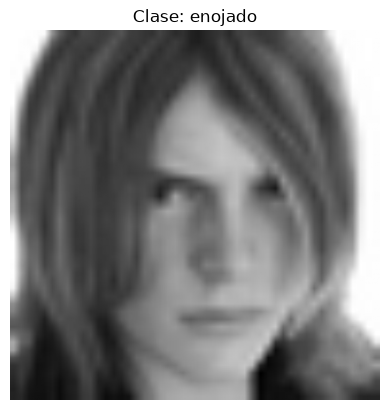

In [7]:
imagen, etiqueta = train_dataset[50]

plt.imshow(
    imagen.permute(1, 2, 0),
    cmap="gray"
)

plt.title(
    f"Clase: {train_dataset.classes[etiqueta]}"
)

plt.axis("off")
plt.show()

In [8]:
BATCH_SIZE = 16

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

len(train_dataloader), len(val_dataloader), len(test_dataloader)

(59, 10, 10)

In [9]:
class TinyVGG(nn.Module):

    def __init__(
        self,
        input_shape: int,
        hidden_units: int,
        output_shape: int
    ):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0
            ),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0
            ),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                in_features=hidden_units * 87 * 87,
                out_features=output_shape
            )
        )

    def forward(self, x):

        x = self.conv_block_1(x)
        # print(x.shape)

        x = self.conv_block_2(x)
        # print(x.shape)

        x = self.classifier(x)
        # print(x.shape)

        return x

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

model_0 = TinyVGG(
    input_shape=1,
    hidden_units=8,
    output_shape=len(train_dataset.classes)
).to(device)

model_0

Dispositivo: cuda


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=60552, out_features=4, bias=True)
  )
)

In [11]:
image_batch, label_batch = next(
    iter(train_dataloader)
)

print("Forma de las imágenes:")
print(image_batch.shape)

print("Forma de las etiquetas:")
print(label_batch.shape)

Forma de las imágenes:
torch.Size([16, 1, 360, 360])
Forma de las etiquetas:
torch.Size([16])


In [12]:
model_0(image_batch.to(device))

tensor([[ 0.0248,  0.0383,  0.0395, -0.0415],
        [ 0.0235,  0.0403,  0.0399, -0.0437],
        [ 0.0240,  0.0373,  0.0377, -0.0427],
        [ 0.0275,  0.0364,  0.0360, -0.0437],
        [ 0.0238,  0.0426,  0.0341, -0.0427],
        [ 0.0226,  0.0385,  0.0375, -0.0399],
        [ 0.0225,  0.0400,  0.0401, -0.0436],
        [ 0.0233,  0.0418,  0.0365, -0.0464],
        [ 0.0257,  0.0423,  0.0349, -0.0428],
        [ 0.0241,  0.0364,  0.0372, -0.0413],
        [ 0.0300,  0.0423,  0.0351, -0.0450],
        [ 0.0263,  0.0412,  0.0376, -0.0435],
        [ 0.0259,  0.0368,  0.0394, -0.0462],
        [ 0.0266,  0.0440,  0.0324, -0.0455],
        [ 0.0337,  0.0377,  0.0364, -0.0414],
        [ 0.0241,  0.0444,  0.0335, -0.0466]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [13]:
summary(
    model_0,
    input_size=(1, 1, 360, 360)
)

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 4]                    --
├─Sequential: 1-1                        [1, 8, 178, 178]          --
│    └─Conv2d: 2-1                       [1, 8, 358, 358]          80
│    └─ReLU: 2-2                         [1, 8, 358, 358]          --
│    └─Conv2d: 2-3                       [1, 8, 356, 356]          584
│    └─ReLU: 2-4                         [1, 8, 356, 356]          --
│    └─MaxPool2d: 2-5                    [1, 8, 178, 178]          --
├─Sequential: 1-2                        [1, 8, 87, 87]            --
│    └─Conv2d: 2-6                       [1, 8, 176, 176]          584
│    └─ReLU: 2-7                         [1, 8, 176, 176]          --
│    └─Conv2d: 2-8                       [1, 8, 174, 174]          584
│    └─ReLU: 2-9                         [1, 8, 174, 174]          --
│    └─MaxPool2d: 2-10                   [1, 8, 87, 87]            --
├─Sequential

In [14]:
def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device=device):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def val_step(model,
             dataloader,
             loss_fn,
             optimizer,
             device=device):
    model.eval ()
    val_loss, val_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            val_pred_logits = model(X)
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()
            y_pred_class = torch.argmax(val_pred_logits, dim=1)
            val_acc += (y_pred_class == y).sum().item()/len(val_pred_logits)
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc

In [15]:
from torch.utils.data import Subset


debug_dataset = ImageFolder(
    root=train_directory,
    transform=transform_test
)


debug_indices = []


for class_index in range(
    len(debug_dataset.classes)
):

    indices_for_class = [
        index
        for index, target
        in enumerate(debug_dataset.targets)
        if target == class_index
    ]

    debug_indices.extend(
        indices_for_class[:8]
    )


small_dataset = Subset(
    debug_dataset,
    debug_indices
)


small_dataloader = DataLoader(
    small_dataset,
    batch_size=8,
    shuffle=True
)


small_model = TinyVGG(
    input_shape=1,
    hidden_units=10,
    output_shape=4
).to(device)


small_loss_fn = nn.CrossEntropyLoss()


small_optimizer = torch.optim.Adam(
    small_model.parameters(),
    lr=0.001
)


for epoch in range(30):

    small_loss, small_acc = train_step(
        model=small_model,
        dataloader=small_dataloader,
        loss_fn=small_loss_fn,
        optimizer=small_optimizer,
        device=device
    )

    if (
        epoch == 0
        or (epoch + 1) % 5 == 0
    ):

        print(
            f"Época {epoch + 1}: "
            f"loss={small_loss:.4f}, "
            f"accuracy={small_acc:.4f}"
        )

Época 1: loss=2.0765, accuracy=0.1562
Época 5: loss=1.3695, accuracy=0.2500
Época 10: loss=0.9928, accuracy=0.6562
Época 15: loss=0.5979, accuracy=0.8125
Época 20: loss=0.0471, accuracy=1.0000
Época 25: loss=0.0707, accuracy=0.9688
Época 30: loss=0.0043, accuracy=1.0000


In [16]:
def train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss_fn,
    epochs,
    patience=10,
    min_delta=0.001,
    min_epochs=15,
    device=device
):

    results = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")

    # Cuenta cuántas épocas consecutivas no presentan mejora
    epochs_without_improvement = 0

    MODEL_PATH = "model_trained/"
    MODEL_NAME = "EnojadoFelizNormalTriste.pth"
    MODEL_SAVE_PATH = MODEL_PATH + MODEL_NAME

    for epoch in tqdm(range(epochs)):

        # Entrenamiento
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        # Validación
        val_loss, val_acc = val_step(
            model=model,
            dataloader=val_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        # Se considera una mejora cuando val_loss disminuye
        # al menos la cantidad indicada en min_delta
        if val_loss < best_val_loss - min_delta:

            best_val_loss = val_loss

            # Reiniciar el contador porque sí hubo mejora
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                MODEL_SAVE_PATH
            )

            improvement_message = (
                "Mejor modelo guardado"
            )

        else:

            # Aumentar contador porque no hubo mejora
            epochs_without_improvement += 1

            improvement_message = (
                f"Sin mejora: "
                f"{epochs_without_improvement}/{patience}"
            )

        print(
            f"Epoch: {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} "
            f"Train acc: {train_acc:.4f} | "
            f"Val loss: {val_loss:.4f} "
            f"Val acc: {val_acc:.4f} | "
            f"{improvement_message}"
        )

        results["train_loss"].append(
            train_loss
        )

        results["train_acc"].append(
            train_acc
        )

        results["val_loss"].append(
            val_loss
        )

        results["val_acc"].append(
            val_acc
        )

        # La parada temprana solo se permite después
        # de completar el mínimo de épocas
        if (
            epoch + 1 >= min_epochs
            and epochs_without_improvement >= patience
        ):

            print(
                "\nEntrenamiento detenido anticipadamente."
            )

            print(
                f"Se completaron al menos "
                f"{min_epochs} épocas."
            )

            print(
                f"La pérdida de validación no mejoró "
                f"al menos {min_delta} durante "
                f"{patience} épocas consecutivas."
            )

            print(
                f"Épocas ejecutadas: "
                f"{epoch + 1}"
            )

            print(
                f"Mejor pérdida de validación: "
                f"{best_val_loss:.4f}"
            )

            print(
                f"El mejor modelo quedó guardado en: "
                f"{MODEL_SAVE_PATH}"
            )

            break

    return results

In [ ]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


NUM_EPOCHS = 30


model_0 = TinyVGG(
    input_shape=1,
    hidden_units=10,
    output_shape=len(train_dataset.classes)
).to(device)


loss_fn = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    params=model_0.parameters(),
    lr=0.001
)


print(model_0)


# Comprobar que el optimizador pertenece al modelo actual
optimizer_is_connected = (
    optimizer.param_groups[0]["params"][0]
    is list(model_0.parameters())[0]
)


print(
    "¿El optimizador está conectado al modelo?",
    optimizer_is_connected
)

In [18]:
start_time = timer()


model_0_results = train(
    model=model_0,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    patience=5,
    min_delta=0.001,
    min_epochs=8
)


end_time = timer()


print(
    f"Tiempo de entrenamiento: "
    f"{end_time - start_time:.3f} segundos"
)

  3%|▎         | 1/30 [01:10<33:57, 70.25s/it]

Epoch: 1/30 | Train loss: 1.4919 Train acc: 0.2405 | Val loss: 1.3867 Val acc: 0.1750 | Mejor modelo guardado


  7%|▋         | 2/30 [02:19<32:35, 69.83s/it]

Epoch: 2/30 | Train loss: 1.3865 Train acc: 0.2504 | Val loss: 1.3863 Val acc: 0.2500 | Sin mejora: 1/5


 10%|█         | 3/30 [03:28<31:10, 69.29s/it]

...

Epoch: 6/30 | Train loss: 1.3863 Train acc: 0.2545 | Val loss: 1.3863 Val acc: 0.2500 | Sin mejora: 5/5


 23%|██▎       | 7/30 [08:08<26:50, 70.01s/it]

Epoch: 7/30 | Train loss: 1.3889 Train acc: 0.2616 | Val loss: 1.3863 Val acc: 0.2500 | Sin mejora: 6/5


 23%|██▎       | 7/30 [09:20<30:43, 80.14s/it]

Epoch: 8/30 | Train loss: 1.3863 Train acc: 0.2555 | Val loss: 1.3863 Val acc: 0.2500 | Sin mejora: 7/5

Entrenamiento detenido anticipadamente.
Se completaron al menos 8 épocas.
La pérdida de validación no mejoró al menos 0.001 durante 5 épocas consecutivas.
Épocas ejecutadas: 8
Mejor pérdida de validación: 1.3867
El mejor modelo quedó guardado en: model_trained/EnojadoFelizNormalTriste.pth
Tiempo de entrenamiento: 560.950 segundos


In [ ]:
MODEL_PATH = "model_trained/"

MODEL_NAME = "EnojadoFelizNormalTriste.pth"

MODEL_SAVE_PATH = (
    MODEL_PATH
    + MODEL_NAME
)


model_0 = TinyVGG(
    input_shape=1,
    hidden_units=10,
    output_shape=len(train_dataset.classes)
).to(device)


model_0.load_state_dict(
    torch.load(
        MODEL_SAVE_PATH,
        map_location=device
    )
)


model_0.eval()


print(
    "Mejor modelo cargado correctamente."
)

In [19]:
def plot_loss_curves(results):
    train_loss = results["train_loss"]
    test_loss = results["val_loss"]
    train_acc = results["train_acc"]
    test_acc = results["val_acc"]
    epochs = range(len(train_loss))
    
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

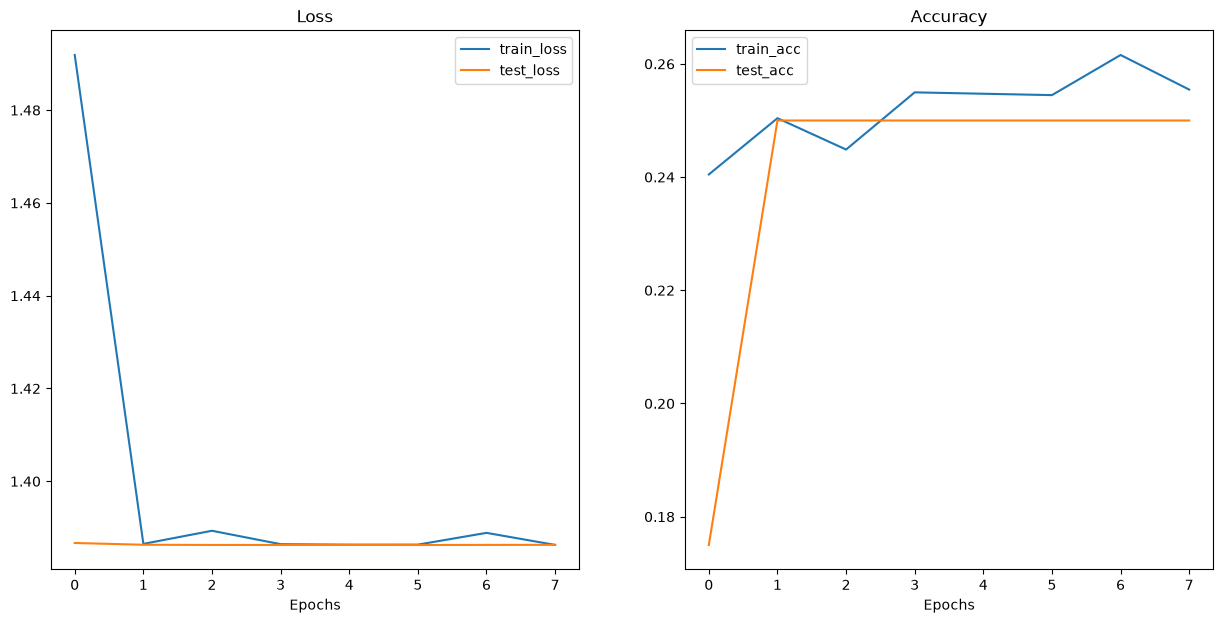

In [20]:
plot_loss_curves(model_0_results)

In [21]:
model_0 = TinyVGG(
    input_shape=1,
    hidden_units=10,
    output_shape=len(train_dataset.classes)
).to(device)


MODEL_PATH = "model_trained/"

MODEL_NAME = "EnojadoFelizNormalTriste.pth"

MODEL_SAVE_PATH = (
    MODEL_PATH
    + MODEL_NAME
)


model_0.load_state_dict(
    torch.load(
        MODEL_SAVE_PATH,
        map_location=device
    )
)


model_0.eval()


print(
    "Mejor modelo cargado correctamente."
)

print(
    "Modelo cargado desde:",
    MODEL_SAVE_PATH
)

Mejor modelo cargado correctamente.
Modelo cargado desde: model_trained/EnojadoFelizNormalTriste.pth


In [22]:
def make_predictions(model, dataloader, device):
    pred_class = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred_logits = model(X)
            pred_prob = torch.softmax(pred_logits, dim=1)
            pred_class.append(torch.argmax(pred_prob, dim=1))
    return torch.hstack(pred_class)

In [23]:
pred_classes = make_predictions(
    model=model_0,
    dataloader=test_dataloader,
    device=device
)
pred_classes

tensor([2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1,
        1, 2, 1, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2,
        1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2,
        1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1,
        1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1,
        2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2], device='cuda:0')

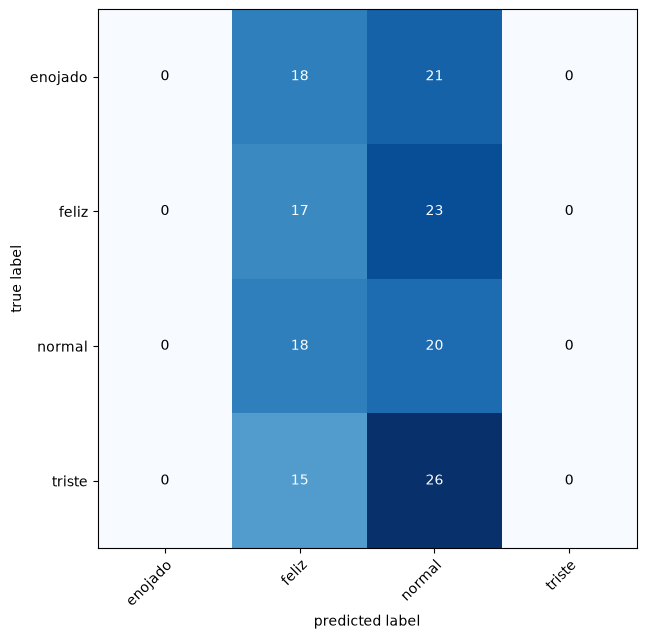

In [24]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

%matplotlib inline


confmat = ConfusionMatrix(
    task="multiclass",
    num_classes=4
)


true_labels = torch.tensor(
    test_dataset.targets,
    dtype=torch.int64
)


predicted_labels = (
    pred_classes
    .cpu()
    .to(torch.int64)
)


confmat_tensor = confmat(
    predicted_labels,
    true_labels
)


fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=test_dataset.classes,
    figsize=(10, 7)
)

In [25]:
from sklearn.metrics import classification_report
pred_cpu = pred_classes.cpu().numpy()
test_dataset.targets
print(classification_report(y_true=test_dataset.targets, y_pred=pred_cpu, target_names=test_dataset.classes))

              precision    recall  f1-score   support

     enojado       0.00      0.00      0.00        39
       feliz       0.25      0.42      0.31        40
      normal       0.22      0.53      0.31        38
      triste       0.00      0.00      0.00        41

    accuracy                           0.23       158
   macro avg       0.12      0.24      0.16       158
weighted avg       0.12      0.23      0.15       158



c:\env\gestos\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\env\gestos\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\env\gestos\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
test_sample = []
test_label = []

for sample, label in test_dataset:
    test_sample.append(sample)
    test_label.append(label)

test_sample[0].shape

torch.Size([1, 360, 360])

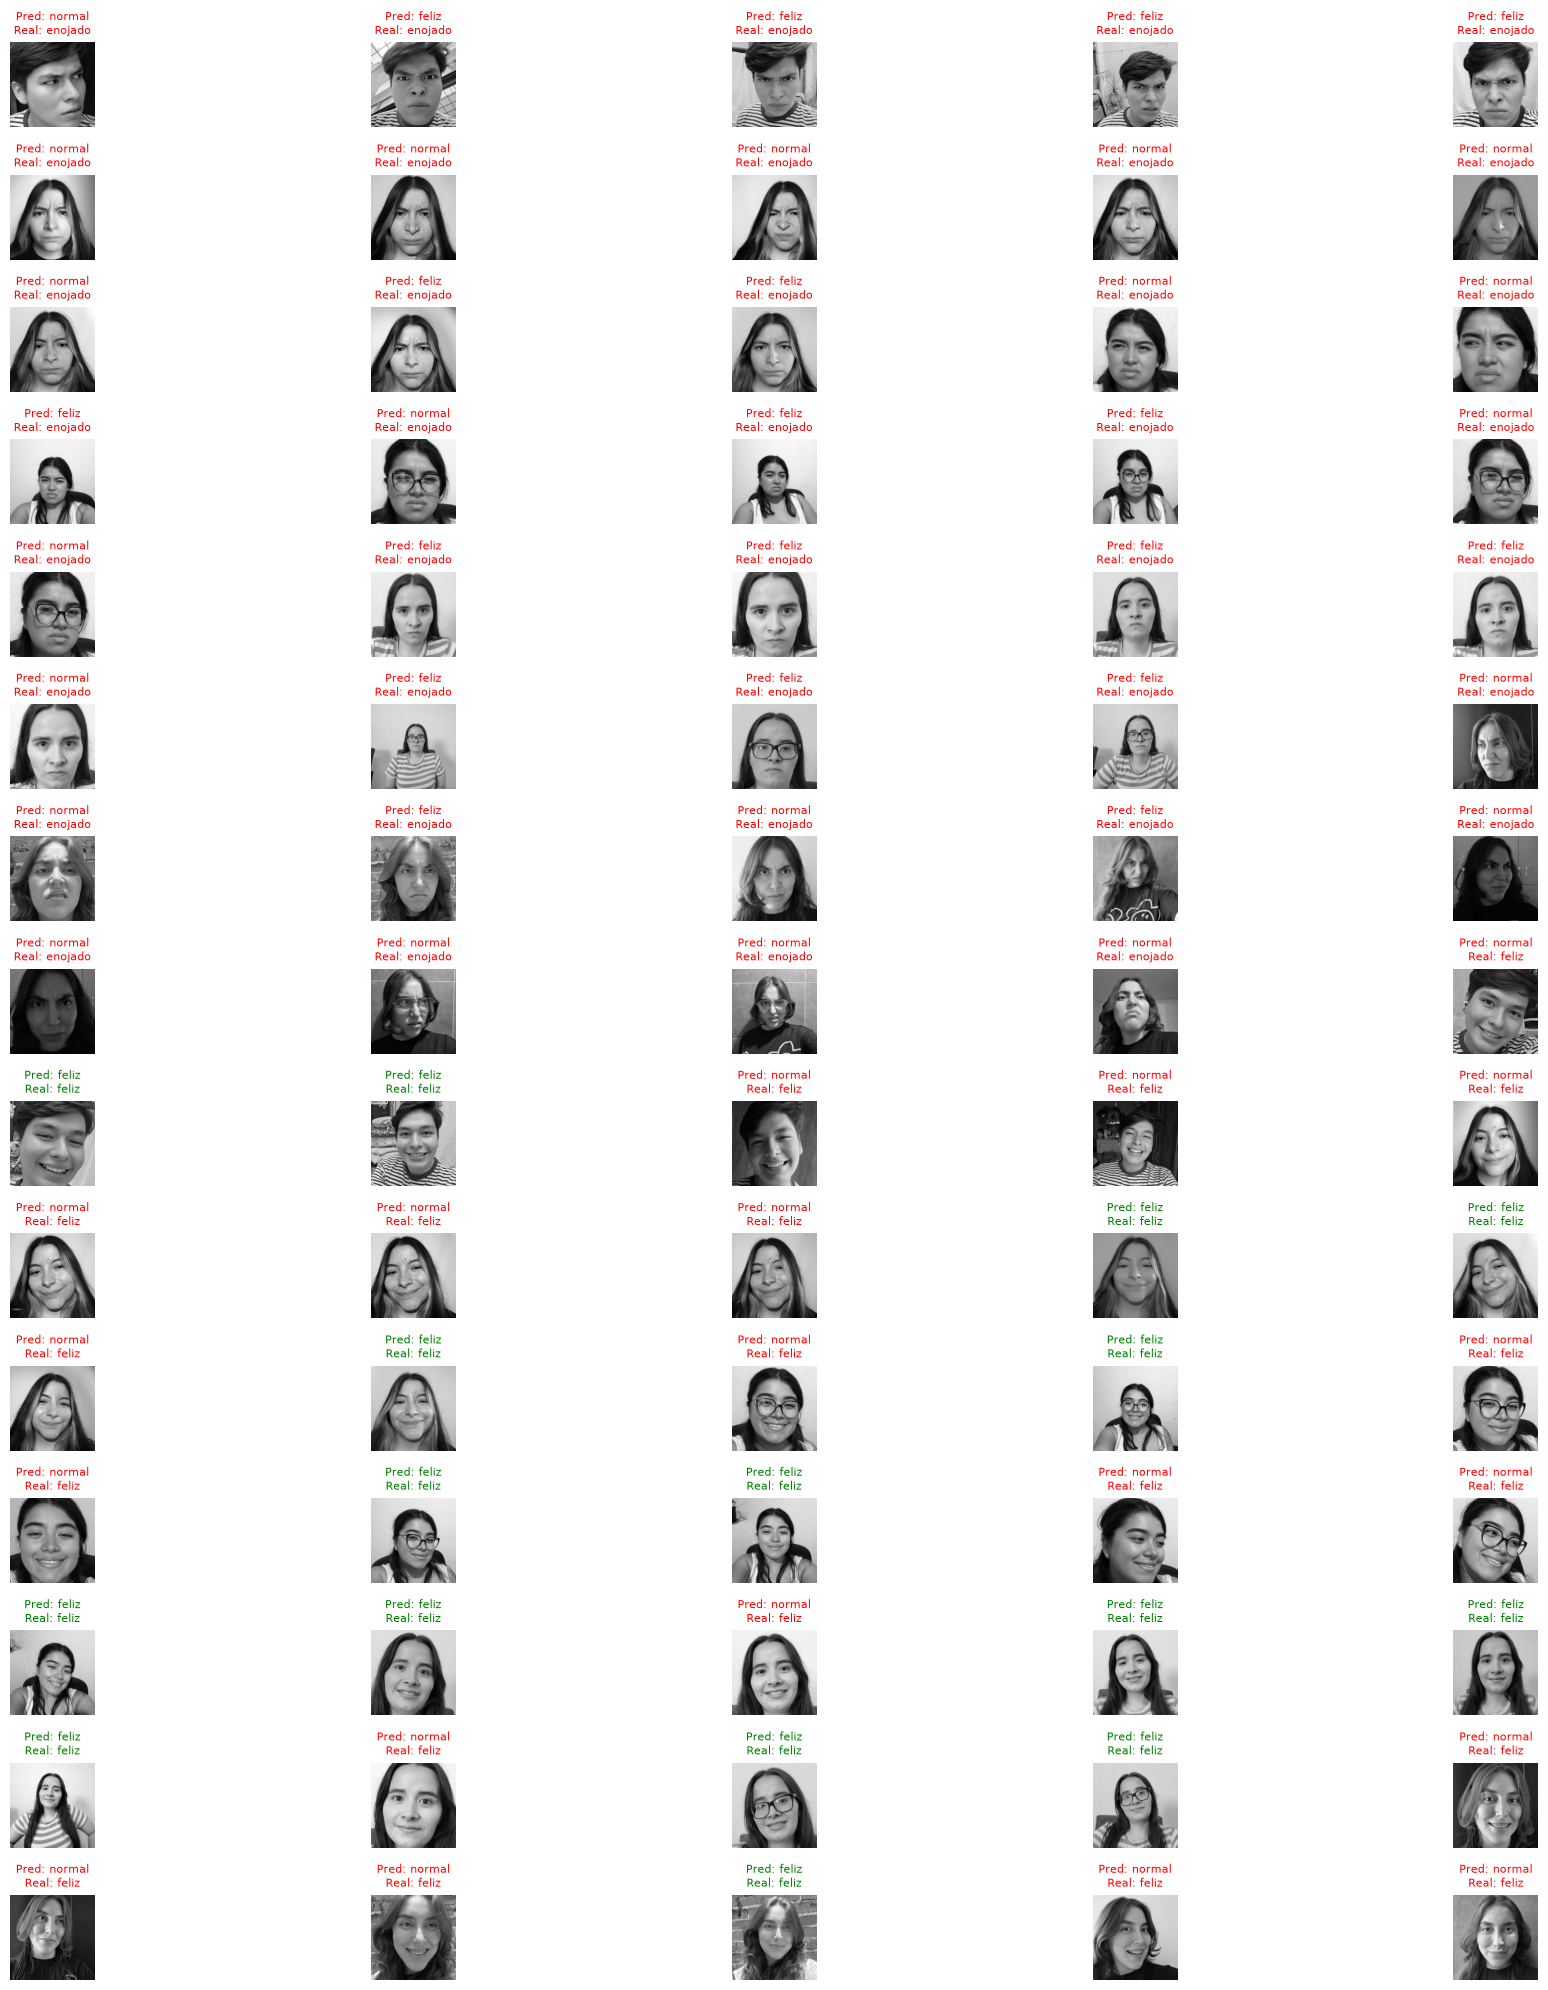

In [27]:
plt.figure(
    figsize=(20, 20)
)

nrows = 15
ncols = 5

# La cuadrícula admite como máximo 75 imágenes
max_images = min(
    len(test_dataset),
    nrows * ncols
)

for i in range(max_images):

    sample, real_label = test_dataset[i]

    plt.subplot(
        nrows,
        ncols,
        i + 1
    )

    plt.imshow(
        sample.permute(1, 2, 0),
        cmap="gray"
    )

    # Convertir el tensor de predicción a un número entero
    predicted_index = pred_classes[i].item()

    pred_label = test_dataset.classes[
        predicted_index
    ]

    truth_label = test_dataset.classes[
        real_label
    ]

    title_text = (
        f"Pred: {pred_label}\n"
        f"Real: {truth_label}"
    )

    if pred_label == truth_label:

        plt.title(
            title_text,
            fontsize=8,
            color="green"
        )

    else:

        plt.title(
            title_text,
            fontsize=8,
            color="red"
        )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import torch


face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades
    + "haarcascade_frontalface_default.xml"
)


cap = cv2.VideoCapture(
    0,
    cv2.CAP_DSHOW
)


cap.set(
    cv2.CAP_PROP_FRAME_WIDTH,
    640
)

cap.set(
    cv2.CAP_PROP_FRAME_HEIGHT,
    480
)


frame_counter = 0

last_label = "Esperando rostro"

last_confidence = 0.0


model_0.eval()


if not cap.isOpened():

    print(
        "Error: no se pudo abrir la cámara."
    )

else:

    while True:

        ret, frame = cap.read()

        if not ret:

            print(
                "Error: no se pudo obtener el fotograma."
            )

            break


        gray = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2GRAY
        )


        faces = face_detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(120, 120)
        )


        if len(faces) > 0:

            # Elegir el rostro más grande
            x, y, w, h = max(
                faces,
                key=lambda face: (
                    face[2] * face[3]
                )
            )


            # Agregar un pequeño margen
            margin_x = int(
                w * 0.15
            )

            margin_y = int(
                h * 0.15
            )


            x1 = max(
                0,
                x - margin_x
            )

            y1 = max(
                0,
                y - margin_y
            )

            x2 = min(
                gray.shape[1],
                x + w + margin_x
            )

            y2 = min(
                gray.shape[0],
                y + h + margin_y
            )


            face_gray = gray[
                y1:y2,
                x1:x2
            ]


            frame_counter += 1


            # Predecir solo cada cinco fotogramas
            if frame_counter % 5 == 0:

                resized = cv2.resize(
                    face_gray,
                    (360, 360)
                )


                tensor = (
                    transforms
                    .ToTensor()(resized)
                    .unsqueeze(0)
                    .to(device)
                )


                with torch.inference_mode():

                    pred_logits = model_0(
                        tensor
                    )


                    probabilities = torch.softmax(
                        pred_logits,
                        dim=1
                    )


                    confidence, pred_class = torch.max(
                        probabilities,
                        dim=1
                    )


                last_label = test_dataset.classes[
                    pred_class.item()
                ]


                last_confidence = (
                    confidence.item()
                    * 100
                )


            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )


            text = (
                f"{last_label}: "
                f"{last_confidence:.1f}%"
            )


            cv2.putText(
                frame,
                text,
                (
                    x1,
                    max(30, y1 - 10)
                ),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

        else:

            cv2.putText(
                frame,
                "Rostro no detectado",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 0, 255),
                2
            )


        cv2.imshow(
            "Reconocimiento de emociones",
            frame
        )


        key = cv2.waitKey(1) & 0xFF

        if key == ord("q"):
            break


cap.release()

cv2.destroyAllWindows()

KeyboardInterrupt: 